<a href="https://colab.research.google.com/github/MannySan2004/Deep-Learning-utilizing-tensor-flow/blob/main/Manuel_HW9_IEE3593_DL_Basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#### IEE3593
# Big Data Analysis
## Week3. Deep Learning
***
Instructor: Jungmin Han, jhan@yonsei.ac.kr <br>
***

Pease copy this colab notebook and rename it before you start!

---

In [ ]:
# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dropout, Flatten, Dense
import tensorflow_hub as hub

# Commonly used modules
import numpy as np
import os
import sys

# Images, plots, display, and visualization
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import cv2
import IPython
from six.moves import urllib
import PIL.Image
import time
import functools

print(tf.__version__)


2.19.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 01. Neural Network Regression with TensorFlow


| **Hyperparameter** | **Typical value** |
| --- | --- |
| Input layer shape | Same shape as number of features (e.g. 3 for # bedrooms, # bathrooms, # car spaces in housing price prediction) |
| Hidden layer(s) | Problem specific, minimum = 1, maximum = unlimited |
| Neurons per hidden layer | Problem specific, generally 10 to 100 |
| Output layer shape | Same shape as desired prediction shape (e.g. 1 for house price) |
| Hidden activation | Usually [ReLU](https://www.kaggle.com/dansbecker/rectified-linear-units-relu-in-deep-learning) (rectified linear unit) |
| Output activation | None, ReLU, logistic/tanh |
| Loss function | [MSE](https://en.wikipedia.org/wiki/Mean_squared_error) (mean square error) or [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) (mean absolute error)/Huber (combination of MAE/MSE) if outliers |
| Optimizer | [SGD](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD) (stochastic gradient descent), [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) |

***Table 1:*** *Typical architecture of a regression network.* ***Source:*** *Adapted from page 293 of [Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow Book by Aurélien Géron](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/)*

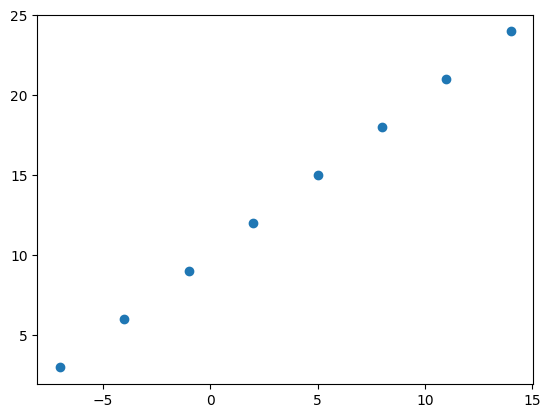

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create features
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y);

In [ ]:
# Let's take a look at the single examples invidually
X[0], y[0]

(np.float64(-7.0), np.float64(3.0))

## Steps in modelling with TensorFlow

Now we know what data we have as well as the input and output shapes, let's see how we'd build a neural network to model it.

In TensorFlow, there are typically 3 fundamental steps to creating and training a model.

1. **Creating a model** - piece together the layers of a neural network yourself (using the [Functional](https://www.tensorflow.org/guide/keras/functional) or [Sequential API](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential)) or import a previously built model (known as transfer learning).
2. **Compiling a model** - defining how a models performance should be measured (loss/metrics) as well as defining how it should improve (optimizer).
3. **Fitting a model** - letting the model try to find patterns in the data (how does `X` get to `y`).

In [ ]:
# Set random seed
tf.random.set_seed(42)

# Create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])  # 1 input feature -> 1 output
])

# Compile the model
# Add mae loss, Add SGD optimizer
model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"]
)

# Fit the model
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - loss: 15.7648 - mae: 15.7648
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 15.4835 - mae: 15.4835
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 15.2023 - mae: 15.2023
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 14.9361 - mae: 14.9361
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 14.8036 - mae: 14.8036
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 14.6711 - mae: 14.6711
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 14.5386 - mae: 14.5386
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 14.4061 - mae: 14.4061
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 14.2736 - mae: 14.2736
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 14.1411 - mae: 14.1411
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 14.0086 - mae: 14.0086
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 13.8761 - mae: 13.8761
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━

In [ ]:
# Check out X and y
X, y

(array([-7., -4., -1.,  2.,  5.,  8., 11., 14.]),
 array([ 3.,  6.,  9., 12., 15., 18., 21., 24.]))

In [ ]:
# Try and predict what y would be if X was 17.0
X = 17.0
pred = model.predict(np.array([[X]], dtype=np.float32), verbose=0)
print(pred)

[[29.515406]]


## Improving a model

How do you think you'd improve upon our current model?

If you guessed by tweaking some of the things we did above, you'd be correct.

To improve our model, we alter almost every part of the 3 steps we went through before.

1. **Creating a model** - here you might want to add more layers, increase the number of hidden units (also called neurons) within each layer, change the activation functions of each layer.
2. **Compiling a model** - you might want to choose optimization function or perhaps change the **learning rate** of the optimization function.
3. **Fitting a model** - perhaps you could fit a model for more **epochs** (leave it training for longer) or on more data (give the model more examples to learn from).

In [ ]:
import numpy as np
import tensorflow as tf

# Set random seed
tf.random.set_seed(42)

# Re-initialize X and y to their original values to ensure consistent cardinality
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Ensure X and y are valid numeric arrays with the right shapes
X_train = np.array(X, dtype=np.float32).reshape(-1, 1)  # always (n, 1)
y_train = np.array(y, dtype=np.float32).reshape(-1, 1)  # always (n, 1)

# Create an improved model (more layers, more units, activations)
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compile model (MAE loss + SGD optimizer with specified learning rate)
learning_rate = 0.01
model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
    metrics=["mae"]
)

# Fit model (train longer)
model.fit(X_train, y_train, epochs=100, verbose=1)

# (Optional) Test prediction safely
x_test = np.array([[17.0]], dtype=np.float32)
y_pred = model.predict(x_test, verbose=0)
print("Predicted y for X=17.0:", float(y_pred[0][0]))

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step - loss: 11.9362 - mae: 11.9362
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 11.5972 - mae: 11.5972
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 11.2207 - mae: 11.2207
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 10.7967 - mae: 10.7967
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 10.3126 - mae: 10.3126
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 9.7518 - mae: 9.7518
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 9.0958 - mae: 9.0958
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 8.3172 - mae: 8.3172
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 7.3772 - mae: 7.3772
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 6.2587 - mae: 6.2587
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 4.8710 - mae: 4.8710
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 4.1542 - mae: 4.1542
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━

In [ ]:
# Remind ourselves of what X and y are
X, y

(array([-7., -4., -1.,  2.,  5.,  8., 11., 14.]),
 array([ 3.,  6.,  9., 12., 15., 18., 21., 24.]))

In [ ]:
# Try and predict what y would be if X was 17.0

X = 17.0
pred = model.predict(np.array([[X]], dtype=np.float32), verbose=0)
print(pred)


[[31.779655]]


## Evaluating a model

A typical workflow you'll go through when building neural networks is:

```
Build a model -> evaluate it -> build (tweak) a model -> evaulate it -> build (tweak) a model -> evaluate it...
```

The tweaking comes from maybe not building a model from scratch but adjusting an existing one.

### Visualize, visualize, visualize

When it comes to evaluation, you'll want to remember the words: "visualize, visualize, visualize."

This is because you're probably better looking at something (doing) than you are thinking about something.

It's a good idea to visualize:
* **The data** - what data are you working with? What does it look like?
* **The model itself** - what does the architecture look like? What are the different shapes?
* **The training of a model** - how does a model perform while it learns?
* **The predictions of a model** - how do the predictions of a model line up against the ground truth (the original labels)?

In [ ]:
# Make a bigger dataset
X = np.arange(-100, 100, 4)

# Make labels for the dataset (adhering to the same pattern as before)
y = np.arange(-90, 110, 4)


In [ ]:
# Split data into train and test sets
X_train = X[:40] # first 40 examples (80% of data)
y_train = y[:40]

X_test = X[40:] # last 10 examples (20% of data)
y_test = y[40:]

len(X_train), len(X_test)

(40, 10)

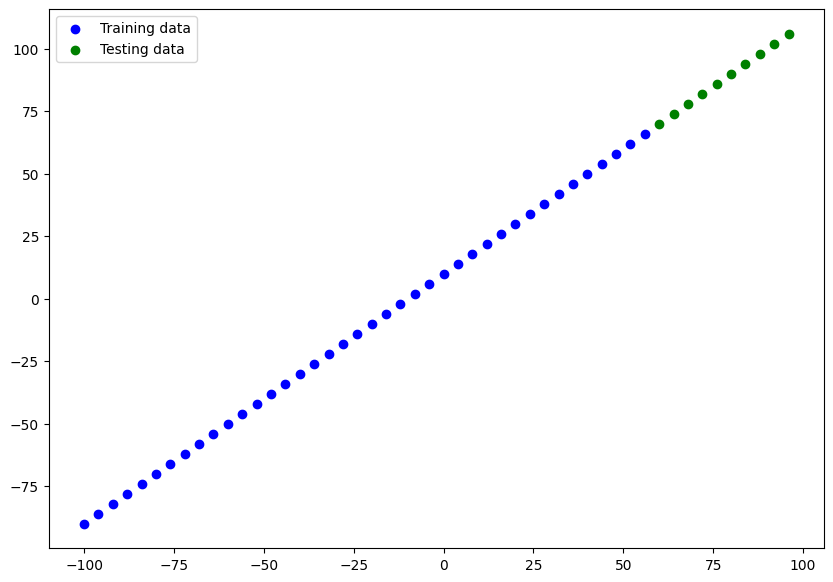

In [ ]:
plt.figure(figsize=(10, 7))
# Plot training data in blue
plt.scatter(X_train, y_train, c='b', label='Training data')
# Plot test data in green
plt.scatter(X_test, y_test, c='g', label='Testing data')
# Show the legend
plt.legend();

In [ ]:
import tensorflow as tf

# Set random seed
tf.random.set_seed(42)

# Create a model (same as above)
model = tf.keras.Sequential([
    # define the input_shape to our model
    tf.keras.layers.Input(shape=(1,)),

    # Your code here (a simple improved architecture)
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compile model (same as above)
model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["mae"]
)


In [ ]:
# This will work after specifying the input shape
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit the model to the training data
model.fit(X_train, y_train, epochs=100, verbose=0) # verbose controls how much gets output

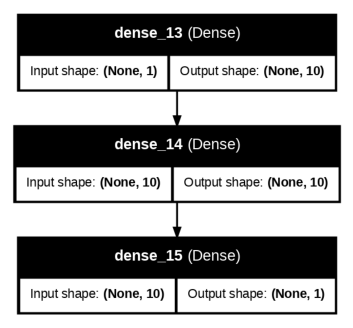

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.utils import plot_model

#Your code here

# Make sure the model is built (required before plotting)
# If you already trained/fitted earlier, this won't hurt.
model.build(input_shape=(None, 1))

# Show the architecture in the notebook (and save a copy)
plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=120,
    to_file="model.png"
)

# Display the saved image
img = plt.imread("model.png")
plt.figure(figsize=(10, 4))
plt.imshow(img)
plt.axis("off")
plt.show()

# (Optional but useful) print a text summary too
model.summary()



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

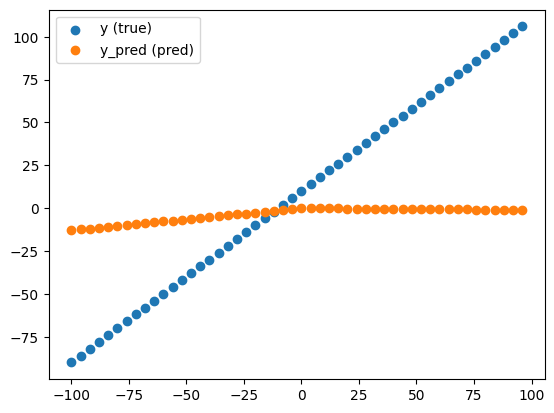

MAE: 47.27094


In [ ]:
# Make predictions
#Your code here
# 1) Visualize the model architecture (won't crash if graphviz isn't installed)
model.build(input_shape=(None, 1))
try:
    plot_model(model, show_shapes=True, show_layer_names=True)
except Exception as e:
    print("plot_model() couldn't render (graphviz/pydot may be missing). Using model.summary() instead.")
model.summary()

# 2) Make predictions using y_pred (safe shapes)
X_eval = np.array(X, dtype=np.float32).reshape(-1, 1)
y_true = np.array(y, dtype=np.float32).reshape(-1, 1)

y_preds = model.predict(X_eval, verbose=0)

# 3) Visualize predictions vs ground truth
plt.figure()
plt.scatter(X_eval, y_true, label="y (true)")
plt.scatter(X_eval, y_pred, label="y_pred (pred)")
plt.legend()
plt.show()

# 4) Quick numeric check (MAE)
mae = np.mean(np.abs(y_true - y_pred))
print("MAE:", mae)


In [ ]:
# View the predictions
y_preds

array([[-12.915142  ],
       [-12.398538  ],
       [-11.881932  ],
       [-11.365328  ],
       [-10.848721  ],
       [-10.332115  ],
       [ -9.815509  ],
       [ -9.298903  ],
       [ -8.782298  ],
       [ -8.265692  ],
       [ -7.7490864 ],
       [ -7.23248   ],
       [ -6.7158747 ],
       [ -6.199269  ],
       [ -5.682664  ],
       [ -5.1660576 ],
       [ -4.6494517 ],
       [ -4.132846  ],
       [ -3.61624   ],
       [ -3.0996344 ],
       [ -2.5830288 ],
       [ -2.066423  ],
       [ -1.5498172 ],
       [ -1.0332115 ],
       [ -0.51660573],
       [  0.        ],
       [ -0.04114779],
       [ -0.08229557],
       [ -0.12344335],
       [ -0.16459115],
       [ -0.20573892],
       [ -0.24688667],
       [ -0.2880345 ],
       [ -0.3291823 ],
       [ -0.37033004],
       [ -0.4114778 ],
       [ -0.4526256 ],
       [ -0.4937734 ],
       [ -0.5349212 ],
       [ -0.576069  ],
       [ -0.6172168 ],
       [ -0.6583646 ],
       [ -0.6995124 ],
       [ -0

In [ ]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=y_preds):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  # Plot the predictions in red (predictions were made on the test data)
  plt.scatter(test_data, predictions, c="r", label="Predictions")
  # Show the legend
  plt.legend();

train sizes: (40,) (40,)
test sizes:  (10,) (10,) (10,)


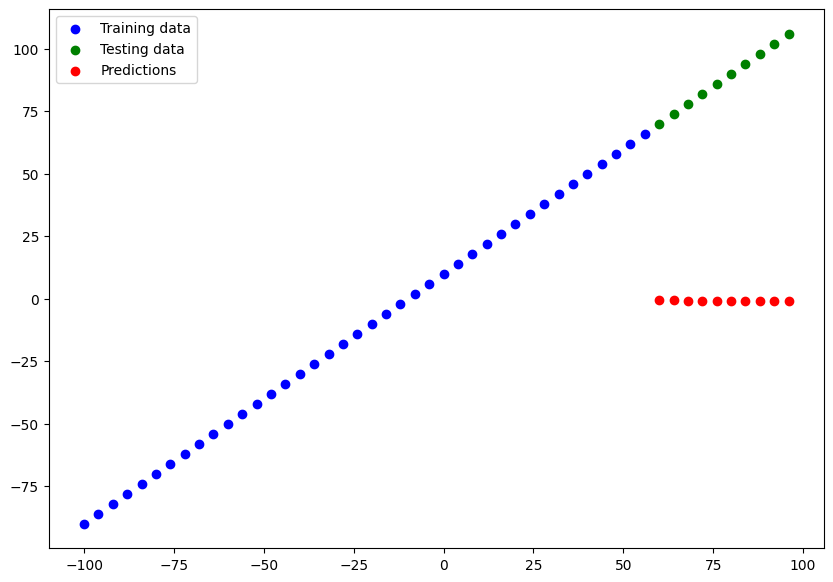

In [ ]:
import numpy as np

# Force all arrays to 1D and make sure lengths match
X_train = np.array(X_train).reshape(-1)
y_train = np.array(y_train).reshape(-1)

X_test  = np.array(X_test).reshape(-1)
y_test  = np.array(y_test).reshape(-1)

# IMPORTANT: predictions must be made on X_test (not X_train)
y_preds = model.predict(X_test, verbose=0).reshape(-1)

# Quick sanity check (these sizes MUST match pairwise)
print("train sizes:", X_train.shape, y_train.shape)
print("test sizes: ", X_test.shape, y_test.shape, y_preds.shape)

plot_predictions(train_data=X_train,
                 train_labels=y_train,
                 test_data=X_test,
                 test_labels=y_test,
                 predictions=y_preds)


## Evaluating predictions

Alongisde visualizations, evaulation metrics are your alternative best option for evaluating your model.

Depending on the problem you're working on, different models have different evaluation metrics.

Two of the main metrics used for regression problems are:
* **Mean absolute error (MAE)** - the mean difference between each of the predictions.
* **Mean squared error (MSE)** - the squared mean difference between of the predictions (use if larger errors are more detrimental than smaller errors).

In [ ]:
# Evaluate the model on the test set
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - loss: 88.8024 - mae: 88.8024


[88.80238342285156, 88.80238342285156]

In [ ]:

mae_metric = tf.keras.metrics.MeanAbsoluteError()
mae_metric.update_state(tf.squeeze(y_test), tf.squeeze(y_preds))

print(mae_metric.result().numpy())

88.80238


In [ ]:
# Check the test label tensor values
y_test

array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

In [ ]:
# Check the predictions tensor values (notice the extra square brackets)
y_preds

array([-0.6172168 , -0.6583646 , -0.6995124 , -0.7406601 , -0.78180784,
       -0.8229556 , -0.86410356, -0.9052512 , -0.9463989 , -0.9875468 ],
      dtype=float32)

In [ ]:
y_test, y_preds.squeeze()

(array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106]),
 array([-0.6172168 , -0.6583646 , -0.6995124 , -0.7406601 , -0.78180784,
        -0.8229556 , -0.86410356, -0.9052512 , -0.9463989 , -0.9875468 ],
       dtype=float32))

# Calculate the MSE
mse = tf.metrics.mean_squared_error(y_true=y_test,
                                    y_pred=y_preds.squeeze())
mse

In [ ]:
def mae(y_test, y_pred):
  """
  Calculuates mean absolute error between y_test and y_preds.
  """
  return tf.metrics.mean_absolute_error(y_test,
                                        y_pred)

def mse(y_test, y_pred):
  """
  Calculates mean squared error between y_test and y_preds.
  """
  return tf.metrics.mean_squared_error(y_test,
                                       y_pred)

  print(mse(y_test, y_preds))

## Saving a model

Once you've trained a model and found one which performs to your liking, you'll probably want to save it for use elsewhere (like a web application or mobile device).

You can save a TensorFlow/Keras model using [`model.save()`](https://www.tensorflow.org/tutorials/keras/save_and_load#save_the_entire_model).

There are two ways to save a model in TensorFlow:
1. The [SavedModel format](https://www.tensorflow.org/tutorials/keras/save_and_load#savedmodel_format) (default).
2. The [HDF5 format](https://www.tensorflow.org/tutorials/keras/save_and_load#hdf5_format).

In [ ]:
FilePath = '/content/drive/MyDrive/Colab Notebooks'

# Save a model using the SavedModel format
model.save(FilePath + 'best_model_SavedModel_format.keras') # Added .keras extension

In [ ]:
# Save a model using the HDF5 format
model.save(FilePath + "/best_model_HDF5_format.h5") # note the addition of '/' and '.h5' on the end

In [ ]:
# Check it out
!ls best_model_HDF5_format.h5

ls: cannot access 'best_model_HDF5_format.h5': No such file or directory


## Loading a model

We can load a saved model using the [`load_model()`](https://www.tensorflow.org/api_docs/python/tf/keras/models/load_model) method.

Loading a model for the different formats (SavedModel and HDF5) is the same (as long as the pathnames to the particular formats are correct).

In [ ]:
# Load a model from the SavedModel format
loaded_saved_model = tf.keras.models.load_model(FilePath+"best_model_SavedModel_format.keras")
loaded_saved_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425 (1.66 KB)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 284 (1.11 KB)

In [ ]:
def mae(y_test, y_pred):
    """
    Calculates mean absolute error between y_test and y_pred.
    Returns a Tensor (so you can call .numpy()).
    """
    y_test = tf.cast(tf.reshape(y_test, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    return tf.reduce_mean(tf.abs(y_test - y_pred))

model_2_preds = model.predict(X_test).squeeze()
saved_model_preds = loaded_saved_model.predict(X_test).squeeze()

# Don't use == for floats; use isclose
np.isclose(mae(y_test, saved_model_preds).numpy(),
           mae(y_test, model_2_preds).numpy())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


np.True_

In [ ]:
# Load a model from the HDF5 format
loaded_h5_model = tf.keras.models.load_model("/content/drive/MyDrive/best_model_HDF5_format.h5")
loaded_h5_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143 (576.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
# Compare model_2 with the loaded HDF5 version (should return True)
h5_model_preds = loaded_h5_model.predict(X_test)
mae(y_test, h5_model_preds.squeeze()).numpy() == mae(y_test, model_2_preds.squeeze()).numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step


np.True_

## Downloading a model (from Google Colab)

Say you wanted to get your model from Google Colab to your local machine, you can do one of the following things:
* Right click on the file in the files pane and click 'download'.
* Use the code below.

In [ ]:
# Download the model (or any file) from Google Colab
from google.colab import files
files.download("/content/drive/MyDrive/best_model_HDF5_format.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>